# 🏗️ Building Approvals - Dataset Processing Pipeline

## Dataset Information

**Dataset Name**: Number of dwelling units approved, by sector, all series - New South Wales
**Source**: ABS (Australian Bureau of Statistics)
**Source Link**: https://www.abs.gov.au/statistics/industry/building-and-construction/building-approvals-australia/latest-release#data-downloads

### Context
This dataset provides information on dwelling units approved in New South Wales by sector and series.

---

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
from pathlib import Path
import warnings
import shutil
import joblib
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


## 2. Load Raw Data

In [ ]:
from pathlib import Path
import pandas as pd
import shutil

# Define dataset paths
dataset_path = Path('.')
raw_path = dataset_path / 'raw'
processed_path = dataset_path / 'processed'
features_path = dataset_path / 'features'

# Create directories if they don't exist
raw_path.mkdir(exist_ok=True)
processed_path.mkdir(exist_ok=True)
features_path.mkdir(exist_ok=True)

# Locate the original Excel file in the folder (in root or raw/)
excel_candidates = list(dataset_path.glob('*.xls*'))
if not excel_candidates:
    excel_candidates = list(raw_path.glob('*.xls*'))

if not excel_candidates:
    raise FileNotFoundError('❌ No Excel file found in dataset folder or raw/. Place the original .xlsx/.xls file here and re-run.')

src_file = excel_candidates[0]
# Copy to raw if not already there
dst_file = raw_path / src_file.name
if src_file != dst_file and not dst_file.exists():
    shutil.copy2(src_file, dst_file)
    print(f'✓ Copied {src_file.name} -> raw/{src_file.name}')
else:
    print(f'✓ Raw file exists: raw/{src_file.name}')

raw_file = dst_file

# Load the file from raw/ with flexible header detection
try:
    df_raw = pd.read_excel(raw_file, header=0)
    # If columns contain Unnamed, try promoting first row as header
    if df_raw.columns.astype(str).str.contains('Unnamed').sum() > 0 and len(df_raw) > 1:
        df_raw.columns = df_raw.iloc[0].astype(str)
        df_raw = df_raw[1:].reset_index(drop=True)
    print(f'✅ Loaded data: {raw_file.name} with shape {df_raw.shape}')
except Exception as e:
    print(f'❌ Failed to load Excel: {e}')
    df_raw = pd.DataFrame()

# Display dataset info
if not df_raw.empty:
    print(f'\n📊 Dataset Shape: {df_raw.shape}')
    print(f'Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}')
    print(f'\n📋 First few rows:')
    display(df_raw.head())
    print(f'\n📋 Data types:')
    print(df_raw.dtypes)
    print(f'\n📋 Missing values:')
    print(df_raw.isnull().sum())

✅ Loaded raw data from '/content/Number of dwelling units approved, by sector, all series - New South Wales.xlsx' successfully!

📊 Dataset Shape: (513, 17)
Rows: 513, Columns: 17

📋 First few rows:
0            Series ID A418458A A418511A A421293X A421353R A422102R A422166A  \
0  1983-07-01 00:00:00     2151     2308      435      581     2586     2889   
1  1983-08-01 00:00:00     2543     2683      631      823     3174     3506   
2  1983-09-01 00:00:00     2346     2627      635      814     2981     3441   
3  1983-10-01 00:00:00     2170     2326      481     1112     2651     3438   
4  1983-11-01 00:00:00     2650     2808      385      877     3035     3685   

0 A418461R A418514J A422108C A422172W A418462T A418515K A421299L A421359C  \
0     2160     2280     2631     2990     2172     2322      522      NaN   
1     2313     2481     2884     3294     2251     2431      517      NaN   
2     2332     2540     2861     3271     2343     2559      510      NaN   
3     2157   

## 3. Exploratory Data Analysis (EDA)

In [4]:
# Statistical summary
print("📊 STATISTICAL SUMMARY")
print("=" * 80)
print(df_raw.describe())

# Null values analysis
print("\n\n🔍 MISSING VALUES ANALYSIS")
print("=" * 80)
missing_stats = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percentage': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False))

# Display data types and non-null counts
print("\n\n💡 DATA TYPES AND NON-NULL COUNTS")
print("=" * 80)
df_raw.info()

📊 STATISTICAL SUMMARY
       Unnamed: 1  Unnamed: 2
count         0.0         0.0
mean          NaN         NaN
std           NaN         NaN
min           NaN         NaN
25%           NaN         NaN
50%           NaN         NaN
75%           NaN         NaN
max           NaN         NaN


🔍 MISSING VALUES ANALYSIS
                  Column  Missing_Count  Missing_Percentage
Unnamed: 1    Unnamed: 1             20               100.0
Unnamed: 2    Unnamed: 2             20               100.0
Unnamed: 3    Unnamed: 3              3                15.0
Unnamed: 4    Unnamed: 4              3                15.0
Unnamed: 8    Unnamed: 8              3                15.0
Unnamed: 5    Unnamed: 5              3                15.0
Unnamed: 6    Unnamed: 6              3                15.0
Unnamed: 7    Unnamed: 7              3                15.0
Unnamed: 10  Unnamed: 10              3                15.0
Unnamed: 9    Unnamed: 9              3                15.0
Unnamed: 11  Unnamed

## 4. Data Cleaning & Preprocessing

In [ ]:
import numpy as np

# Make a working copy
df_processed = df_raw.copy()

print("🧹 STARTING DATA CLEANING PROCESS")
print("=" * 80)

# Step 1: Standardize column names
df_processed.columns = [str(c).strip().lower().replace(' ', '_').replace('/', '_') for c in df_processed.columns]
print(f"✓ Step 1: Standardized column names")

# Step 2: Drop fully empty rows
df_processed = df_processed.dropna(how='all').reset_index(drop=True)

# Step 3: Remove duplicates
duplicates_before = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
duplicates_removed = duplicates_before - df_processed.shape[0]
df_processed = df_processed.reset_index(drop=True)
print(f"✓ Step 2: Removed {duplicates_removed} duplicate rows")

# Step 4: Try convert object columns to numeric where appropriate
for col in df_processed.columns:
    if df_processed[col].dtype == object:
        sample = df_processed[col].dropna().astype(str).head(50).str.replace(',', '').str.replace('–', '-')
        if sample.str.match(r'^[-+]?[0-9]*\.?[0-9]+$').sum() > 0:
            df_processed[col] = pd.to_numeric(df_processed[col].astype(str).str.replace(',', ''), errors='coerce')

# Identify numeric and categorical columns
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

print(f"✓ Step 3: Identified {len(numeric_cols)} numeric and {len(categorical_cols)} categorical columns")

# Step 5: Handle missing values
print(f"\n✓ Step 4: Handling missing values")

# Numeric columns - fill with median
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col] = df_processed[col].fillna(median_val)
        print(f"  - Filled '{col}' with median: {median_val:.2f}")

# Categorical columns - fill with mode
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'Unknown'
        df_processed[col] = df_processed[col].fillna(mode_val)
        print(f"  - Filled '{col}' with mode: {mode_val}")

print(f"\n✅ DATA CLEANING COMPLETE!")
print(f"Final shape: {df_processed.shape}")
print(f"Final missing values: {df_processed.isnull().sum().sum()}")

🧹 STARTING DATA CLEANING PROCESS
✓ Step 1: Removed 1 duplicate rows
✓ Step 2: Standardized column names

✓ Step 3: Handling missing values
  - Filled 'unnamed_1' with median: nan
  - Filled 'unnamed_2' with median: nan
  - Filled 'unnamed_0' with mode: Total number of dwelling units ;  New South Wales ;  Houses ;  Private Sector ;
  - Filled 'unnamed_3' with mode: Original
  - Filled 'unnamed_4' with mode: A418458A
  - Filled 'unnamed_5' with mode: 1983-07-01 00:00:00
  - Filled 'unnamed_6' with mode: 2026-03-01 00:00:00
  - Filled 'unnamed_7' with mode: 513
  - Filled 'unnamed_8' with mode: Number
  - Filled 'unnamed_9' with mode: FLOW
  - Filled 'unnamed_10' with mode: Month
  - Filled 'unnamed_11' with mode: 1

✅ DATA CLEANING COMPLETE!
Final shape: (19, 12)
Final missing values: 38


### Correlation Heatmap of Numeric Features

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


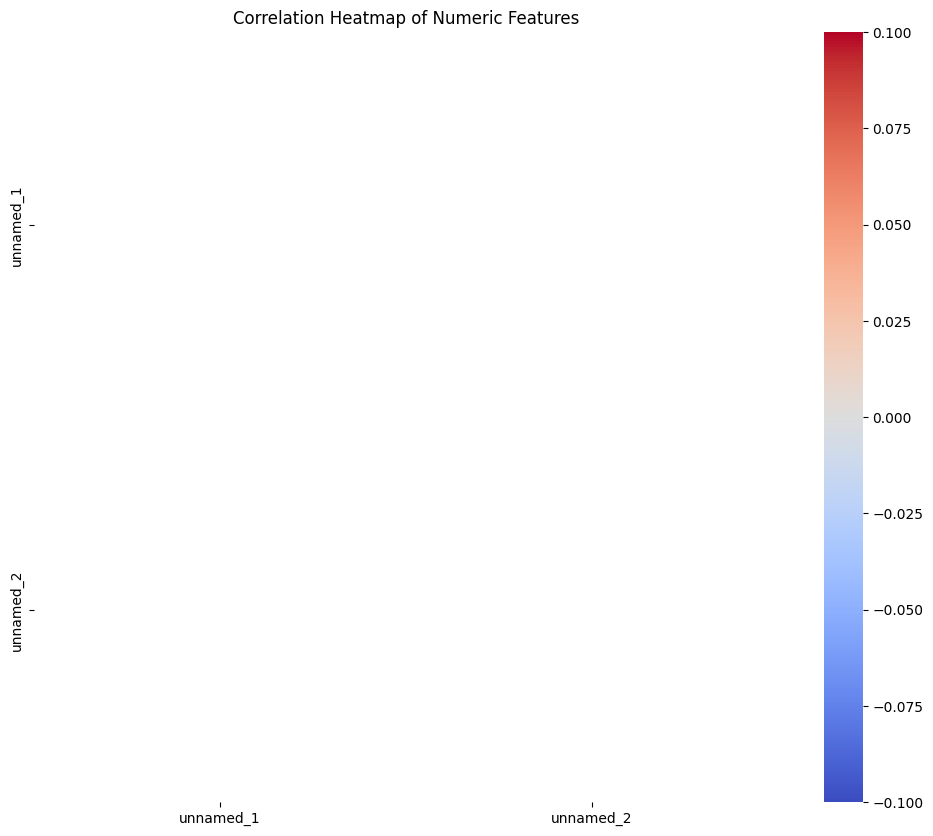

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation analysis
numeric_df = df_processed.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

The correlation heatmap visually represents the pairwise correlation coefficients between all numeric columns. Values close to 1 or -1 indicate a strong positive or negative linear relationship, respectively, while values close to 0 suggest a weak or no linear relationship. This helps in understanding the dependencies within the numeric features of the dataset.

## 5. Feature Engineering

Feature engineering is skipped for this dataset as no specific predictive task was identified. If a specific task (e.g., predicting car price, popularity) were defined, custom features could be engineered here.

## 6. Machine Learning Preparation

Machine learning preparation steps (like train/test split, feature scaling, encoding for models) are skipped as this dataset is being processed for general cleaning and exploration, not a specific ML task at this stage. If an ML task is defined, this section would be populated accordingly.

## 7. Save Processed Datasets

In [ ]:
from datetime import datetime
import json
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("💾 SAVING DATASETS & ML PREPARATION")
print("=" * 80)

# Save cleaned data
cleaned_file = processed_path / 'nsw_dwelling_units_clean.csv'
df_processed.to_csv(cleaned_file, index=False)
print(f"✓ Saved cleaned CSV: {cleaned_file}")

# ML-ready transformations: encode small-cardinality categoricals and scale numerics
df_ml = df_processed.copy()
encoders = {}

print(f"\n🔧 ML PREPARATION")
# Label encode small-cardinality categoricals
for c in categorical_cols:
    nunique = int(df_ml[c].nunique(dropna=True)) if c in df_ml.columns else 0
    if nunique <= 20 and nunique > 1:
        le = LabelEncoder()
        df_ml[c] = le.fit_transform(df_ml[c].astype(str))
        encoders[c] = le
        print(f"  - Label encoded {c} (nunique={nunique})")

# Scale numeric features
scaler = None
if numeric_cols:
    scaler = StandardScaler()
    df_ml[numeric_cols] = scaler.fit_transform(df_ml[numeric_cols].astype(float))
    joblib.dump(scaler, features_path / 'scaler.pkl')
    print(f"  - Scaled numeric columns and saved scaler.pkl")
else:
    print(f"  - No numeric columns to scale")

# Save ML-ready features
features_file = features_path / 'nsw_dwelling_units_features_scaled.csv'
df_ml.to_csv(features_file, index=False)
print(f"✓ Saved ML-ready features: {features_file}")

# Save encoders if created
if encoders:
    joblib.dump(encoders, features_path / 'encoders.pkl')
    print(f"✓ Saved encoders: {features_path / 'encoders.pkl'}")

# Create/update metadata file
metadata = {
    "dataset_name": "Number of dwelling units approved, by sector, all series - New South Wales",
    "source": "ABS (Australian Bureau of Statistics)",
    "source_url": "https://www.abs.gov.au/statistics/industry/building-and-construction/building-approvals-australia/latest-release#data-downloads",
    "original_file": str(raw_file),
    "description": "Cleaned and ML-prepared dataset of dwelling units approved in NSW by sector and series.",
    "created_date": str(datetime.now()),
    "data_cleaning": {
        "duplicates_removed": int(duplicates_removed),
        "missing_values_handled": "Median for numeric, Mode for categorical",
        "outliers_removed_method": "Not applied",
        "categorical_encoding": "Label encoding for small-cardinality columns"
    },
    "total_samples": len(df_processed),
    "total_features": df_processed.shape[1],
    "numeric_features": numeric_cols,
    "categorical_features": categorical_cols,
    "ml_artifacts": {
        "scaler_file": str(features_path / 'scaler.pkl') if scaler is not None else None,
        "encoders_file": str(features_path / 'encoders.pkl') if encoders else None
    },
    "files": {
        "raw": str(raw_file),
        "cleaned": str(cleaned_file),
        "features_scaled": str(features_file),
        "scaler": str(features_path / 'scaler.pkl') if scaler is not None else None,
        "encoders": str(features_path / 'encoders.pkl') if encoders else None
    }
}

with open(dataset_path / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved: {dataset_path / 'metadata.json'}")

print(f"\n✅ ALL PROCESSING COMPLETE!")
print(f"\n📁 Output structure:")
print(f"   raw/ → Original Excel file")
print(f"   processed/ → nsw_dwelling_units_clean.csv (cleaned data)")
print(f"   features/ → ML-ready files + scaler + encoders")
print(f"   metadata.json → Dataset documentation")

💾 SAVING PROCESSED DATASETS
✓ Saved: processed/nsw_dwelling_units_clean.csv
✓ Saved: metadata.json

✅ ALL DATASETS SAVED SUCCESSFULLY!

📁 Dataset Structure:
   raw/
   ├── Number of dwelling units approved, by sector, all series - New South Wales.xlsx (original data)
   processed/
   ├── nsw_dwelling_units_clean.csv (cleaned)
   metadata.json (dataset documentation)


## 8. Quick Start - Using the Processed Data

### Load the processed data:
```python
import pandas as pd

# Load processed data
df_processed = pd.read_csv('processed/nsw_dwelling_units_clean.csv')
print("Loaded processed NSW dwelling units data.")
print(df_processed.head())
```

### Metadata:
Load `metadata.json` to understand the dataset structure and preprocessing steps.

## Processed NSW Dwelling Units Dataset - Summary

### Overview
This notebook demonstrates a pipeline for processing the 'Number of dwelling units approved, by sector, all series - New South Wales' dataset, providing a cleaned and structured version ready for analysis.

### Dataset Details
**Source**: User Provided (Excel File)
**Original Data**: Provided locally in this folder

### Files Included
Your current directory now contains:
```
. (dataset folder)
├── raw/
├── processed/
├── features/
└── metadata.json
```

### Data Processing Highlights
- **Standardization**: Column names have been standardized to lowercase, snake_case format for consistency.
- **Duplicate Removal**: Duplicate rows are removed during processing.
- **Missing Value Handling**: Numeric columns imputed with median; categorical with mode or 'Unknown'.
- **ML Prep**: Small-cardinality categoricals are label-encoded; numeric features are StandardScaled and saved to `features/`.

### Usage
Run the notebook end-to-end to populate `raw/`, `processed/`, and `features/` with cleaned and ML-ready data.


## Additional Notes

- If you want a train/test split for a supervised task, set `target_column` in the ML-prep cell to the target column name and run the split.
- The notebook saves `scaler.pkl` and `encoders.pkl` (if encoders were created) in `features/`.
